<a href="https://colab.research.google.com/github/Mehar-shan/Analyzing-Remote-Work-Productivity-using-t-Test-and-ANOVA/blob/main/CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from torchvision import datasets
train_data = datasets.CIFAR10(root="./data", train=True, download=True)
test_data  = datasets.CIFAR10(root="./data", train=False, download=True)

100%|██████████| 170M/170M [00:03<00:00, 43.6MB/s]


In [45]:
import os

def get_folder_size_mb(folder_path):
    total_size = 0

    for root, dirs, files in os.walk(folder_path):
        for file in files:
            file_path = os.path.join(root, file)
            if os.path.isfile(file_path):
                total_size += os.path.getsize(file_path)

    return total_size / (1024 ** 2)


# 👇 IMPORTANT: set correct root paths
train_path = "/content/dataset/train"
test_path = "/content/dataset/test"

print("Train folder size (MB):", round(get_folder_size_mb(train_path), 2))
print("Test folder size (MB):", round(get_folder_size_mb(test_path), 2))

Train folder size (MB): 107.81
Test folder size (MB): 21.56


In [2]:
# get the classes name of train data
Train_classes = train_data.classes
print(Train_classes)

['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


In [3]:
# get the classes name of test data
Test_classes = test_data.classes
print(Test_classes)

['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


In [4]:
import os

# create folders
os.makedirs("./dataset/train", exist_ok=True)
os.makedirs("./dataset/test", exist_ok=True)

classes = train_data.classes

# create class folders
for cls in classes:
    os.makedirs(f"./dataset/train/{cls}", exist_ok=True)
    os.makedirs(f"./dataset/test/{cls}", exist_ok=True)

# save train images
for i in range(len(train_data)):
    img, label = train_data[i]
    class_name = classes[label]

    img.save(f"./dataset/train/{class_name}/{i}.png")

# save test images
for i in range(len(test_data)):
    img, label = test_data[i]
    class_name = classes[label]

    img.save(f"./dataset/test/{class_name}/{i}.png")

In [5]:
import os
from PIL import Image
import torch
from torch.utils.data import Dataset

class CustomDataset(Dataset):

    def __init__(self, root_dir, transform=None):
        self.image_paths = []
        self.targets = []
        self.transform = transform

        classes = os.listdir(root_dir)
        classes.sort()

        for i in range(len(classes)):
            class_name = classes[i]
            class_folder = os.path.join(root_dir, class_name)

            for img_name in os.listdir(class_folder):
                img_path = os.path.join(class_folder, img_name)

                self.image_paths.append(img_path)
                self.targets.append(i)


    def __len__(self):
        return len(self.image_paths)


    def __getitem__(self, idx):
        image = Image.open(self.image_paths[idx]).convert("RGB")
        label = self.targets[idx]

        if self.transform:
            image = self.transform(image)

        return {
            "sample": image,
            "target": torch.tensor(label, dtype=torch.long)
        }

In [6]:
from torchvision import transforms

transform = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5),
                         (0.5, 0.5, 0.5))
])

In [7]:
train_dataset = CustomDataset("./dataset/train", transform=transform)
test_dataset  = CustomDataset("./dataset/test", transform=transform)

In [43]:
from torch.utils.data import DataLoader

BATCH_SIZE = 32

train_dataloader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

test_dataloader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print(f"Dataloaders: {train_dataloader, test_dataloader}")
print(f"Train batches: {len(train_dataloader)}")
print(f"Test batches: {len(test_dataloader)}")

Dataloaders: (<torch.utils.data.dataloader.DataLoader object at 0x7b051a2640b0>, <torch.utils.data.dataloader.DataLoader object at 0x7b051a6cb470>)
Train batches: 1563
Test batches: 313


In [9]:
import torch
import torch.nn as nn

class AlexNet(nn.Module):
    def __init__(self, num_classes=10):
        super(AlexNet, self).__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=3, padding=1),  # changed
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 192, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(192, 384, kernel_size=3, padding=1),
            nn.ReLU(),

            nn.Conv2d(384, 256, kernel_size=3, padding=1),
            nn.ReLU(),

            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256 * 4 * 4, 1024),  # adjusted
            nn.ReLU(),
            nn.Dropout(0.5),

            nn.Linear(1024, 512),
            nn.ReLU(),
            nn.Dropout(0.5),

            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

In [10]:
# from faiq source :
import torch.nn as nn

criterion = nn.CrossEntropyLoss()

In [11]:
import torch
import torch.optim as optim

model = AlexNet(num_classes=10)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

optimizer_sgd = optim.SGD(model.parameters(), lr=0.01)
optimizer_adam = optim.Adam(model.parameters(), lr=0.001)

In [39]:
def train_model(model, train_loader, optimizer, criterion, epochs, device):

    history = {"loss": [], "accuracy": []}

    for epoch in range(epochs):

        total_loss = 0
        correct = 0
        total = 0

        model.train()  # set training mode

        for batch in train_loader:

            images = batch["sample"].to(device)
            labels = batch["target"].to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            # accumulate loss
            total_loss = total_loss + loss.item()

            # predictions (simple way)
            predicted = outputs.argmax(1)

            # update counts
            total = total + len(labels)
            correct = correct + (predicted == labels).sum().item()

        # epoch results
        epoch_loss = total_loss / len(train_loader)
        epoch_acc = (correct / total) * 100

        history["loss"].append(epoch_loss)
        history["accuracy"].append(epoch_acc)

        print(f"Epoch {epoch + 1}: Loss = {epoch_loss:.4f}, Accuracy = {epoch_acc:.2f}%")

    return model, history

In [13]:
# Save the model's weights to a file named 'model_weights.pth'
torch.save(model.state_dict(), 'model_weights.pth')

In [38]:
import torch

def evaluate_model(model, test_loader, criterion, device):

    model.eval()

    total_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():

        for batch in test_loader:

            images = batch["sample"].to(device)
            labels = batch["target"].to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            # add loss
            total_loss = total_loss + loss.item()

            # get predicted class (simple way)
            predicted = outputs.argmax(1)

            # update counts
            total = total + len(labels)
            correct = correct + (predicted == labels).sum().item()

    # final accuracy
    accuracy = (correct / total) * 100

    # average loss (more meaningful than total loss)
    avg_loss = total_loss / len(test_loader)

    return accuracy, avg_loss

In [15]:
import matplotlib.pyplot as plt

def plot_history(history):

    # Loss plot
    plt.figure()
    plt.plot(history["loss"])
    plt.title("Loss vs Epochs")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.show()

    # Accuracy plot
    plt.figure()
    plt.plot(history["accuracy"])
    plt.title("Accuracy vs Epochs")
    plt.xlabel("Epochs")
    plt.ylabel("Accuracy")
    plt.show()

In [16]:
model, history = train_model(
    model,
    train_dataloader,
    optimizer_adam,   # or optimizer_sgd
    criterion,
    epochs=10,
    device=device
)

Epoch 1: Loss = 2512.398, Accuracy = 39.77%
Epoch 2: Loss = 1819.499, Accuracy = 58.83%
Epoch 3: Loss = 1543.784, Accuracy = 65.53%
Epoch 4: Loss = 1361.345, Accuracy = 69.97%
Epoch 5: Loss = 1228.823, Accuracy = 73.02%
Epoch 6: Loss = 1126.292, Accuracy = 75.40%
Epoch 7: Loss = 1048.227, Accuracy = 77.10%
Epoch 8: Loss = 973.423, Accuracy = 78.60%
Epoch 9: Loss = 928.554, Accuracy = 79.87%
Epoch 10: Loss = 863.273, Accuracy = 81.12%


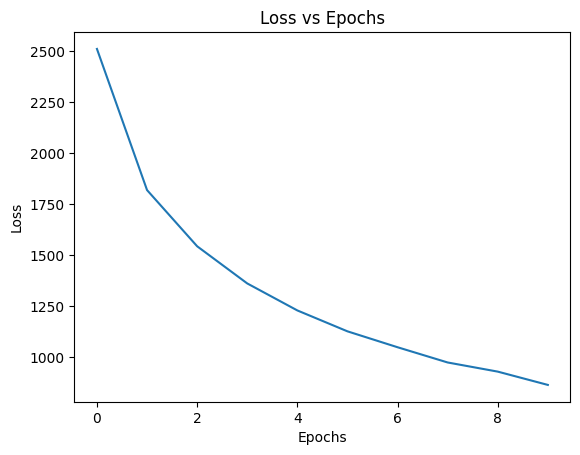

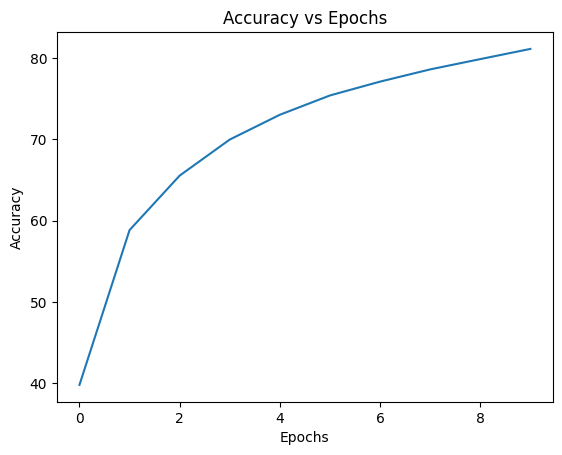

In [18]:
plot_history(history)

In [20]:
# Experiment 01
model = AlexNet(num_classes=10).to(device)

optimizer = torch.optim.SGD(model.parameters(), lr=0.01)

model, history = train_model(
    model,
    train_dataloader,
    optimizer,
    criterion,
    epochs=5,
    device=device
)

test_acc, test_loss = evaluate_model(
    model,
    test_dataloader,
    criterion,
    device
)

print("Test Accuracy:", test_acc)

Epoch 1: Loss = 3598.651, Accuracy = 10.26%
Epoch 2: Loss = 3574.352, Accuracy = 15.17%
Epoch 3: Loss = 3068.644, Accuracy = 25.65%
Epoch 4: Loss = 2679.699, Accuracy = 35.61%
Epoch 5: Loss = 2489.393, Accuracy = 40.61%
Test Accuracy: 44.71


In [21]:
model = AlexNet(num_classes=10).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

model, history = train_model(
    model,
    train_dataloader,
    optimizer,
    criterion,
    epochs=10,
    device=device
)

test_acc, test_loss = evaluate_model(
    model,
    test_dataloader,
    criterion,
    device
)

print("Test Accuracy:", test_acc)

Epoch 1: Loss = 2582.976, Accuracy = 38.33%
Epoch 2: Loss = 1870.079, Accuracy = 57.49%
Epoch 3: Loss = 1588.405, Accuracy = 64.79%
Epoch 4: Loss = 1406.048, Accuracy = 68.72%
Epoch 5: Loss = 1267.983, Accuracy = 72.16%
Epoch 6: Loss = 1179.643, Accuracy = 74.07%
Epoch 7: Loss = 1078.813, Accuracy = 76.39%
Epoch 8: Loss = 1005.881, Accuracy = 78.01%
Epoch 9: Loss = 941.245, Accuracy = 79.62%
Epoch 10: Loss = 892.223, Accuracy = 80.59%
Test Accuracy: 73.8


In [22]:
from torch.utils.data import DataLoader

BATCH_SIZE = 64   # changed from 32 → 64

train_dataloader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

test_dataloader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print("Batch size:", BATCH_SIZE)

Batch size: 64


In [23]:
model = AlexNet(num_classes=10).to(device)

In [24]:
import torch.optim as optim

optimizer = optim.Adam(model.parameters(), lr=0.001)

In [35]:
model, history = train_model(
    model,
    train_dataloader,
    optimizer,
    criterion,
    epochs=20,
    device=device
)

test_acc, test_loss = evaluate_model(
    model,
    test_dataloader,
    criterion,
    device
)

print("Test Accuracy:", test_acc)

Epoch 1: Loss = 614.303, Accuracy = 72.43%
Epoch 2: Loss = 499.872, Accuracy = 77.28%
Epoch 3: Loss = 407.037, Accuracy = 81.53%
Epoch 4: Loss = 330.854, Accuracy = 85.07%
Epoch 5: Loss = 263.609, Accuracy = 88.08%
Epoch 6: Loss = 204.030, Accuracy = 90.71%
Epoch 7: Loss = 170.183, Accuracy = 92.37%
Epoch 8: Loss = 137.514, Accuracy = 93.89%
Epoch 9: Loss = 124.630, Accuracy = 94.39%
Epoch 10: Loss = 104.567, Accuracy = 95.38%
Epoch 11: Loss = 94.976, Accuracy = 95.94%
Epoch 12: Loss = 96.595, Accuracy = 95.90%
Epoch 13: Loss = 86.969, Accuracy = 96.35%
Epoch 14: Loss = 85.046, Accuracy = 96.47%
Epoch 15: Loss = 75.242, Accuracy = 96.83%
Epoch 16: Loss = 73.009, Accuracy = 96.92%
Epoch 17: Loss = 77.342, Accuracy = 96.86%
Epoch 18: Loss = 73.940, Accuracy = 97.02%
Epoch 19: Loss = 73.770, Accuracy = 96.95%
Epoch 20: Loss = 64.468, Accuracy = 97.36%
Test Accuracy: 75.75
